In [77]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aakash50897/churn-modellingcsv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'churn-modellingcsv' dataset.
Path to dataset files: /kaggle/input/churn-modellingcsv


In [78]:
!ls /root/.cache/kagglehub/datasets/aakash50897/churn-modellingcsv/versions/1

Churn_Modelling.csv


In [79]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [80]:
## import some basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [81]:
dataset = pd.read_csv(
    "/root/.cache/kagglehub/datasets/aakash50897/churn-modellingcsv/versions/1/Churn_Modelling.csv"
)
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [82]:
## Divide the dataset into independent and dependent features
X = dataset.iloc[:, 3:13]
y = dataset.iloc[:, 13]

In [83]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [84]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [85]:
## Feature Engineering
geography=pd.get_dummies(X['Geography'],drop_first=True,dtype=int)
gender=pd.get_dummies(X['Gender'],drop_first=True,dtype=int)

In [86]:
## concatenate these variables with dataframe
X=X.drop(['Geography','Gender'],axis=1)

In [87]:
X=pd.concat([X,geography,gender],axis=1)

In [88]:
#Splitting the dataset into Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [89]:
#feature scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [90]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [91]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [92]:
X_train.shape

(8000, 11)

In [93]:
## Now lets create the ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [94]:
## Lets initialize the ANN
classifier=Sequential()

In [95]:
## Adding the input layer
classifier.add(Dense(units=11,activation='relu'))

In [96]:
# Adding the first hidden layer
classifier.add(Dense(units=7,activation='relu'))

In [97]:
# Adding the dropout layer to prevent overfitting
classifier.add(Dropout(0.3))

In [98]:
# Adding the second hidden layer
classifier.add(Dense(units=6,activation='relu'))

In [99]:
# Adding the output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [100]:
# to adjust the learning rate
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [101]:
classifier.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

In [102]:
## Early Stopping
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

In [103]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7959 - loss: 0.4571 - val_accuracy: 0.7955 - val_loss: 0.4299
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4169 - val_accuracy: 0.7955 - val_loss: 0.4068
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8280 - loss: 0.3973 - val_accuracy: 0.8406 - val_loss: 0.3938
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8438 - loss: 0.3822 - val_accuracy: 0.8527 - val_loss: 0.3819
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8500 - loss: 0.3765 - val_accuracy: 0.8281 - val_loss: 0.4146
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8507 - loss: 0.3733 - val_accuracy: 0.8436 - val_loss: 0.3895
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8522 - loss: 0.3725 - val_accuracy: 0.8436 - val_loss: 0.3793
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8517 - loss: 0.3686 - 

In [104]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

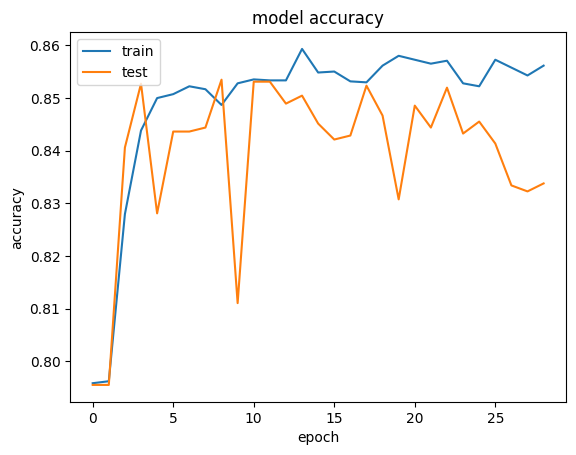

In [105]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

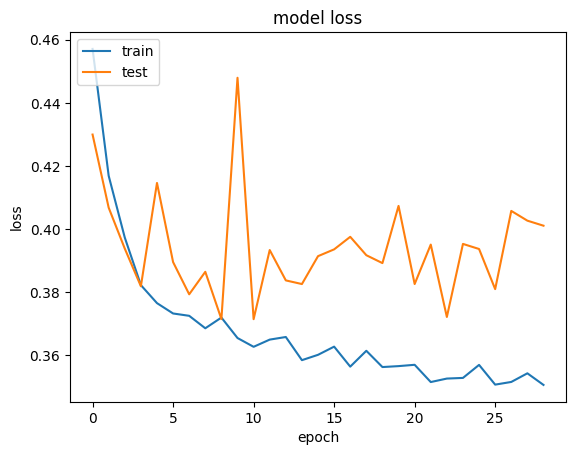

In [106]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [107]:
## Making the predictions and evaluating the model

#predicting the Test set results
y_pred=classifier.predict(X_test)
y_pred=(y_pred>0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [108]:
## make the confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[1392,  203],
       [ 128,  277]])

In [109]:
## Calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

In [110]:
score

0.8345

In [111]:
##get the weights
classifier.get_weights()

[array([[-0.15664685,  0.22032149,  0.04556815,  0.3085266 , -0.23346101,
         -0.12639403,  0.16825362,  0.27793655,  1.6007739 , -0.3628106 ,
         -0.39497375],
        [ 1.7389072 , -0.35962364, -1.6839337 , -0.7340374 , -0.5069778 ,
          0.22411887,  1.4973065 , -0.2945623 , -0.1100481 ,  0.56375927,
         -0.9841013 ],
        [ 0.13918543,  0.15492202, -0.04164812,  0.31073874,  0.65277684,
         -0.21485949, -0.41069302,  0.03381417, -0.5213964 ,  0.17617548,
         -0.22825357],
        [-0.48298326, -1.4732585 , -0.13153833, -1.3696703 ,  0.567716  ,
          0.41400748,  1.4318436 ,  1.8313888 ,  0.3789648 , -1.9058433 ,
         -0.42948318],
        [ 0.468947  ,  1.3426701 ,  0.56106967,  0.714162  , -0.04819889,
          3.319491  ,  0.95144504,  2.4144943 ,  0.68823683, -2.165794  ,
          0.77555877],
        [ 0.22877587, -0.15006903,  0.11022269, -0.8257233 , -0.16914177,
          0.2044091 ,  0.09355731, -0.24027427,  0.581248  ,  0.0876977